<a href="https://colab.research.google.com/github/titan-spyer/ipl_prediction/blob/main/Match_Prediction/analysis/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Add System path for Google Collab Operations
import os
import sys

#Project path to perform Operations
project_path = "/content/ipl_prediction/Match_Prediction/analysis"

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
#Imports for Actual Operations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import missingno as msno

#Local Libraries Imports
from analyze_src.data_inspection import DataInspector, NumericalAnalysis, StatisticalAnalysis

#Setting the Value for clear vision
pd.set_option('display.max_rows', 100) #Display the Max rows to 100
pd.set_option('display.max_columns', None) #Show all columns
pd.set_option('display.max_colwidth', None) #Do Not Truancate the Column
pd.set_option('display.float_format', '{:.2f}'.format) # Show clear Floating values

In [3]:
# Load The Data
data_path = "/content/ipl_prediction/extracted_data"


matches_df = pd.read_csv(os.path.join(data_path, 'matches.csv'))

In [4]:
# Basic Data Inspection
match_inspector = DataInspector(NumericalAnalysis())
#Print the data types
match_inspector.execute_strategy(matches_df, "dtypes")


---Printing Data Types---
id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object


In [16]:
matches_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.00,223.00,20.00,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.00,241.00,20.00,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.00,130.00,20.00,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.00,166.00,20.00,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.00,111.00,20.00,N,NaN,BF Bowden,K Hariharan


In [5]:
# Print the Data Information
match_inspector.execute_strategy(matches_df, "info")

---Printing info of file---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null  

In [6]:
# print missing values
match_inspector.execute_strategy(matches_df, "missing_values")


---Printing Missing Values---
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [7]:
#print duplicate Values
match_inspector.execute_strategy(matches_df, "duplicates")


---Printing Duplicate Values---
0


In [8]:
#Changing the startegy to stastical analysis
match_inspector.set_strategy(StatisticalAnalysis())
#Print Numerical analysis
match_inspector.execute_strategy(matches_df, "numerical")

---Printing Numerical Analysis---
              id  result_margin  target_runs  target_overs
count    1095.00        1076.00      1092.00       1092.00
mean   904828.32          17.26       165.68         19.76
std    367740.24          21.79        33.43          1.58
min    335982.00           1.00        43.00          5.00
25%    548331.50           6.00       146.00         20.00
50%    980961.00           8.00       166.00         20.00
75%   1254062.50          20.00       187.00         20.00
max   1426312.00         146.00       288.00         20.00


In [9]:
#Print Categorical Analysis
match_inspector.execute_strategy(matches_df, "categorical")

---Printing Categorical Analysis---
       season    city        date match_type player_of_match         venue  \
count    1095    1044        1095       1095            1090          1095   
unique     17      36         823          8             291            58   
top      2013  Mumbai  2008-04-26     League  AB de Villiers  Eden Gardens   
freq       76     173           2       1029              25            77   

                              team1           team2     toss_winner  \
count                          1095            1095            1095   
unique                           19              19              19   
top     Royal Challengers Bangalore  Mumbai Indians  Mumbai Indians   
freq                            135             138             143   

       toss_decision          winner   result super_over method       umpire1  \
count           1095            1090     1095       1095     21          1095   
unique             2              19        4          

# Data inspection & Missing Value calculation


*   After analyzing the above method we have seen that the data doesn't contain any duplicate values
*   Most of the Data is filled only the method contain missing values we are planning to ignore that column because it won't impact that much
* For other data like player of the match and result margin we will perform univariate and multivariate analysis with heat map so that we can get a clear instict what to do with those missing values
* Final verdict till now is data is clean and not messy after these two steps after variate analysis we will look up to its IQR then we will do our decisions upon feature engineering



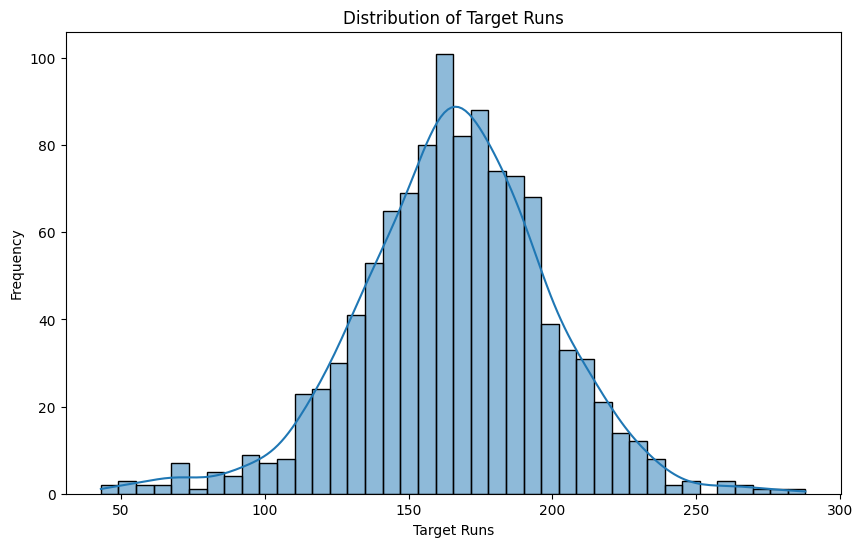

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(matches_df['target_runs'], kde=True, bins=40)
plt.title('Distribution of Target Runs')
plt.xlabel('Target Runs')
plt.ylabel('Frequency')
plt.show()

# Univariate analysis on Target Runs
* we observe that most of the target relies between 150-200 now this data is made for old era cricket as per morden era cricket 250 will must a winning score we will perform bivariate analysis with season also to observe which season what is the winnig score
* we will also perform the bivariate analysis with venues to observe which venue score large which score small

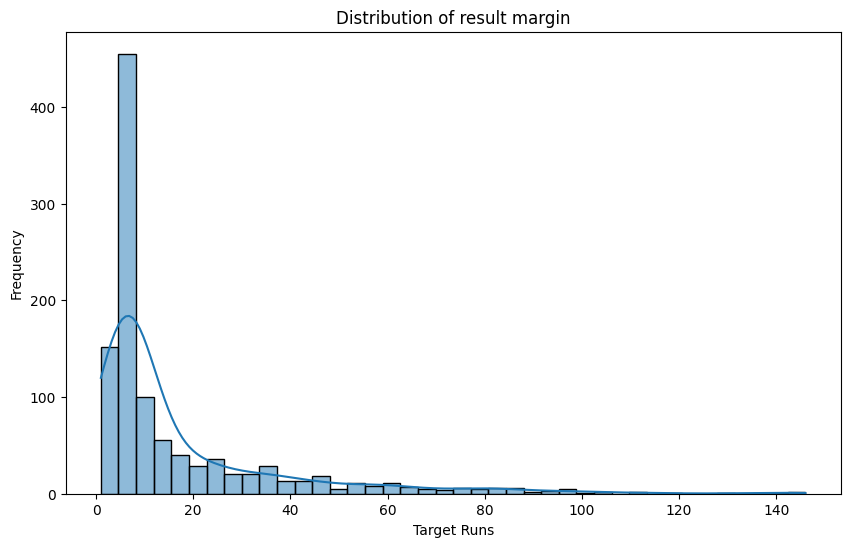

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(matches_df['result_margin'], kde=True, bins=40)
plt.title('Distribution of result margin')
plt.xlabel('Result Margin')
plt.ylabel('Frequency')
plt.show()

# univariate on Result margin
* As per this is not that much important now because it contains the score with the wicket count we also need bivariate analysis with it's type to get the actual average run margin for future detection with each ball analysis


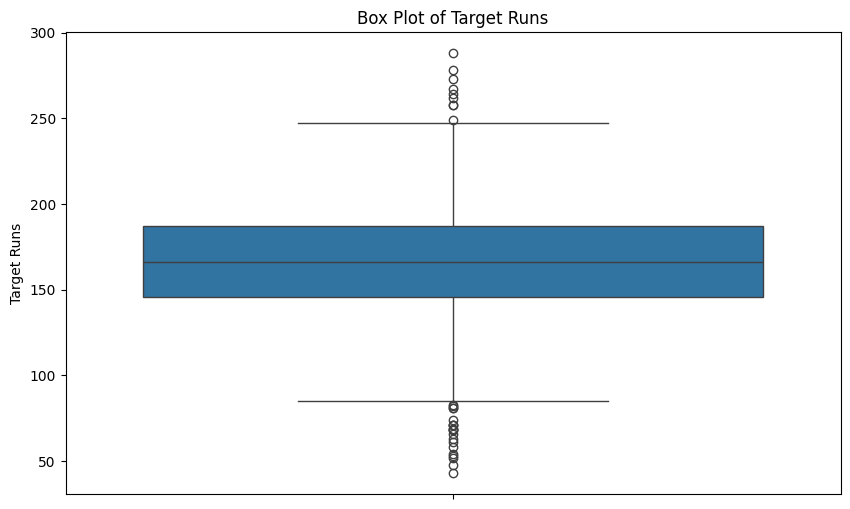

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=matches_df['target_runs'])
plt.title('Box Plot of Target Runs')
plt.ylabel('Target Runs')
plt.show()

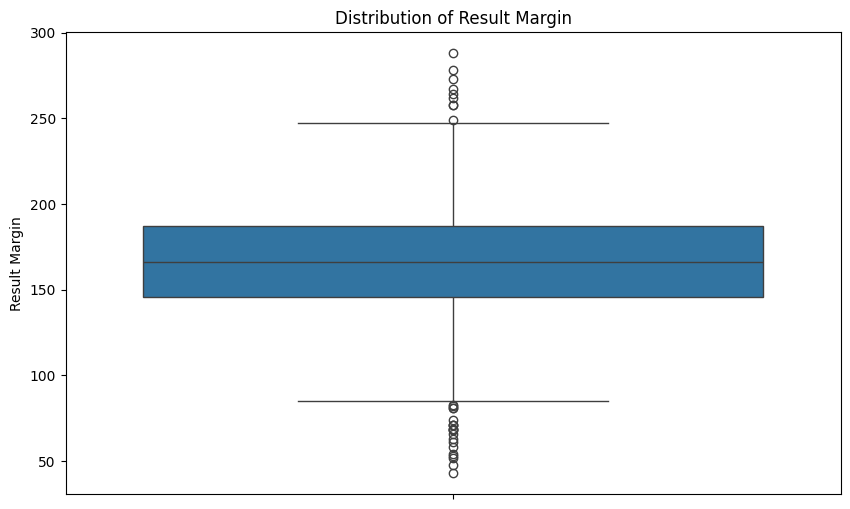

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=matches_df['target_runs'])
plt.title('Distribution of Result Margin')
plt.ylabel('Result Margin')
plt.show()

# Now we will move to Categorical Univariate analysis